In [1]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [17]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [18]:
print(df_train['Irrigation_Need'].value_counts(normalize=True))

Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64


In [19]:
len(df_train.columns)

21

In [20]:
cat_columns = df_train.select_dtypes(include=['category','object','str']).columns.tolist()
numeric_cols = df_train.select_dtypes(include='number').columns.tolist()

In [21]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  str    
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  str    
 12  Crop_Growth_Stage        630000 non-null  str    
 13  Season                   630000 non-null  str    
 14  Irrigation_Type

In [22]:
df_train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [23]:
df_test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [24]:
test_ids = df_test['id'].values

In [25]:
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_train['Irrigation_Need'] = df_train['Irrigation_Need'].map(target_mapping)
# df_test['Irrigation_Need'] = df_test['Irrigation_Need'].map(target_mapping)

In [26]:
df_train_encoded = pd.get_dummies(df_train,drop_first=True)
df_test_encoded = pd.get_dummies(df_test,drop_first=True)

In [27]:
df_train_encoded.columns

Index(['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare',
       'Previous_Irrigation_mm', 'Irrigation_Need', 'Soil_Type_Loamy',
       'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Type_Maize',
       'Crop_Type_Potato', 'Crop_Type_Rice', 'Crop_Type_Sugarcane',
       'Crop_Type_Wheat', 'Crop_Growth_Stage_Harvest',
       'Crop_Growth_Stage_Sowing', 'Crop_Growth_Stage_Vegetative',
       'Season_Rabi', 'Season_Zaid', 'Irrigation_Type_Drip',
       'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler',
       'Water_Source_Rainwater', 'Water_Source_Reservoir',
       'Water_Source_River', 'Mulching_Used_Yes', 'Region_East',
       'Region_North', 'Region_South', 'Region_West'],
      dtype='str')

In [44]:
# What i was doing
# features
# X_train = df_train_encoded.drop(columns='Irrigation_Need').values
# X_test = df_test_encoded.values

# target variables
# Y_train = df_train_encoded['Irrigation_Need'].values
# Y_test = df_test_encoded['Irrigation_Need'].values

# GPT bhai
X_train = df_train_encoded.drop(columns=['Irrigation_Need','id']).values
Y_train = df_train_encoded['Irrigation_Need'].values

print(df_train_encoded.drop(columns=['Irrigation_Need']).columns)


X_test = df_test_encoded.drop(columns=['id']).values

Index(['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare',
       'Previous_Irrigation_mm', 'Soil_Type_Loamy', 'Soil_Type_Sandy',
       'Soil_Type_Silt', 'Crop_Type_Maize', 'Crop_Type_Potato',
       'Crop_Type_Rice', 'Crop_Type_Sugarcane', 'Crop_Type_Wheat',
       'Crop_Growth_Stage_Harvest', 'Crop_Growth_Stage_Sowing',
       'Crop_Growth_Stage_Vegetative', 'Season_Rabi', 'Season_Zaid',
       'Irrigation_Type_Drip', 'Irrigation_Type_Rainfed',
       'Irrigation_Type_Sprinkler', 'Water_Source_Rainwater',
       'Water_Source_Reservoir', 'Water_Source_River', 'Mulching_Used_Yes',
       'Region_East', 'Region_North', 'Region_South', 'Region_West'],
      dtype='str')


In [45]:
print(df_test_encoded.drop(columns=['id']).columns)

Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm',
       'Soil_Type_Loamy', 'Soil_Type_Sandy', 'Soil_Type_Silt',
       'Crop_Type_Maize', 'Crop_Type_Potato', 'Crop_Type_Rice',
       'Crop_Type_Sugarcane', 'Crop_Type_Wheat', 'Crop_Growth_Stage_Harvest',
       'Crop_Growth_Stage_Sowing', 'Crop_Growth_Stage_Vegetative',
       'Season_Rabi', 'Season_Zaid', 'Irrigation_Type_Drip',
       'Irrigation_Type_Rainfed', 'Irrigation_Type_Sprinkler',
       'Water_Source_Rainwater', 'Water_Source_Reservoir',
       'Water_Source_River', 'Mulching_Used_Yes', 'Region_East',
       'Region_North', 'Region_South', 'Region_West'],
      dtype='str')


In [46]:
import optuna
import xgboost as xgb

print(X_train.shape)
print(Y_train.shape)
df_DMatrix = xgb.DMatrix(data=X_train,label=Y_train)

def objective(trial):

    params = {
        "objective": "multi:softmax",
        "num_class": 3,
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "eta": trial.suggest_float("eta", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "eval_metric": "mlogloss",
        "nthread": -1
    }

    cv = xgb.cv(
        params,
        df_DMatrix,
        nfold=4,
        num_boost_round=30,
        early_stopping_rounds=10
    )

    return cv["test-mlogloss-mean"].min()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=4)

print(study.best_params)

(630000, 35)
(630000,)


[I 2026-04-08 21:05:51,858] A new study created in memory with name: no-name-d34c1216-be7a-4c88-b0db-0b91d44a1f9a
[I 2026-04-08 21:06:09,326] Trial 0 finished with value: 0.06894923302853923 and parameters: {'max_depth': 8, 'eta': 0.2610614740074225, 'subsample': 0.689610554935036, 'colsample_bytree': 0.7071149953736686}. Best is trial 0 with value: 0.06894923302853923.
[I 2026-04-08 21:06:24,296] Trial 1 finished with value: 0.5587774455112124 and parameters: {'max_depth': 7, 'eta': 0.017129905541368926, 'subsample': 0.6848922526146558, 'colsample_bytree': 0.6046068044891408}. Best is trial 0 with value: 0.06894923302853923.
[I 2026-04-08 21:06:37,448] Trial 2 finished with value: 0.3010776158254298 and parameters: {'max_depth': 4, 'eta': 0.04827241921963387, 'subsample': 0.7947289399147054, 'colsample_bytree': 0.9957971244091379}. Best is trial 0 with value: 0.06894923302853923.
[I 2026-04-08 21:06:49,335] Trial 3 finished with value: 0.3280295226171731 and parameters: {'max_depth': 

{'max_depth': 8, 'eta': 0.2610614740074225, 'subsample': 0.689610554935036, 'colsample_bytree': 0.7071149953736686}


In [47]:
print(X_train.shape)
print(X_test.shape)

(630000, 35)
(270000, 35)


In [48]:
model = xgb.XGBClassifier(study.best_params)

model.fit(X_train, Y_train)

print(X_train.shape)
print(X_test.shape)

preds = model.predict(X_test)

/Users/apple/Documents Local/Mubashir Code/ML/.venv/lib/python3.12/site-packages/xgboost/core.py:748: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)


(630000, 35)
(270000, 35)


In [55]:
print(len(model.feature_importances_))
print(len(df_train_encoded.columns[(df_train_encoded.columns != 'Irrigation_Need') & (df_train_encoded.columns != 'id')]))


35
35


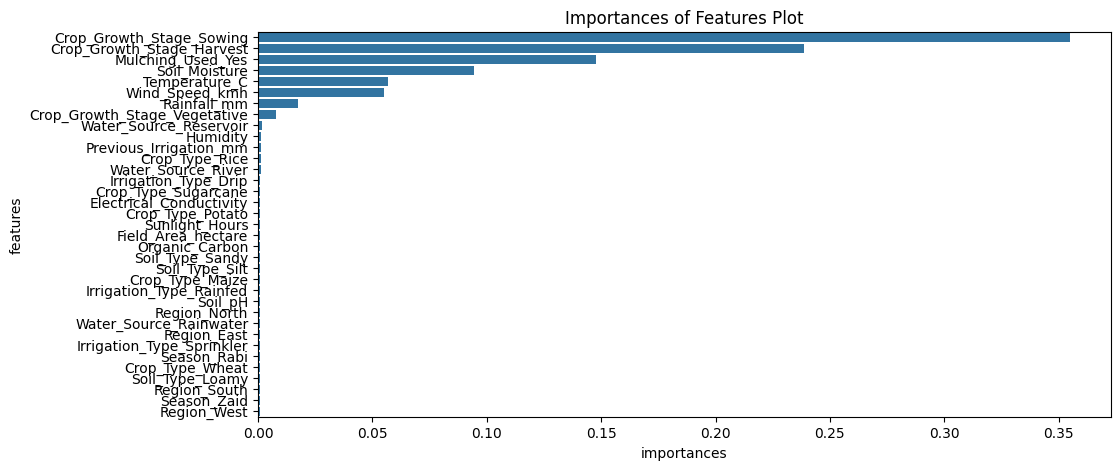

In [57]:
df_plot = pd.DataFrame({'features': df_train_encoded.columns[(df_train_encoded.columns != 'Irrigation_Need') & (df_train_encoded.columns != 'id')],
                        'importances': model.feature_importances_})
df_plot = df_plot.sort_values('importances', ascending=False)
plt.figure(figsize=[11,5])
sns.barplot(x = df_plot.importances, y = df_plot.features)
plt.title('Importances of Features Plot')
plt.show()

In [61]:
submission = pd.DataFrame({'id': test_ids, 'Irrigation_Need': preds})


In [62]:
reverse_map = {0:'Low', 1:'Medium', 3:'High'}
submission['Irrigation_Need'] = submission['Irrigation_Need'].map(reverse_map)

In [63]:
submission.to_csv('submission.csv', index=False)